# 📟 실습 1: 7-Segment 숫자 인식 모델
> **AI Programming Course** — Konan Technology

---

## 학습 목표
- 7-세그먼트 디스플레이의 이진 입력 벡터를 이해한다
- PyTorch `nn.Module`로 MLP(다층 퍼셉트론)를 직접 구현한다
- CrossEntropyLoss + Adam 옵티마이저로 학습 루프를 작성한다
- Confusion Matrix로 분류 결과를 시각화한다

## 실습 구성
| 단계 | 내용 |
|:---:|------|
| 1 | 환경 세팅 및 라이브러리 import |
| 2 | 7-bit 데이터 생성 및 노이즈 증강 |
| 3 | MLP 모델 정의 (`nn.Module`) |
| 4 | 학습 루프 + 손실 그래프 시각화 |
| 5 | 추론 테스트 + Confusion Matrix |
| 6 | ✏️ 도전 과제 |


---
## Step 1: 환경 세팅 및 라이브러리 Import

아래 셀을 실행하여 필요한 패키지를 설치하고 import합니다.

In [1]:
# 필요 패키지 설치 (최초 1회만 실행)
# !pip install torch torchvision matplotlib seaborn scikit-learn

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# 재현성을 위한 시드 고정
np.random.seed(42)
torch.manual_seed(42)

print(f'PyTorch 버전: {torch.__version__}')
print(f'GPU 사용 가능: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'학습 디바이스: {device}')

PyTorch 버전: 2.11.0+cpu
GPU 사용 가능: False
학습 디바이스: cpu


---
## Step 2: 7-Segment 데이터 생성 및 시각화

### 7-Segment 구조
```
 _
|_|   세그먼트 순서: [a, b, c, d, e, f, g]
|_|   a=상단, b=우상, c=우하, d=하단, e=좌하, f=좌상, g=중간
```

각 숫자는 7개의 비트로 표현됩니다 (1=ON, 0=OFF).

In [7]:
# ─── 7-Segment 이상적 패턴 정의 ───────────────────────────────────────────
#         [a, b, c, d, e, f, g]
SEGMENTS = {
    0: [1, 1, 1, 1, 1, 1, 0],
    1: [0, 1, 1, 0, 0, 0, 0],
    2: [1, 1, 0, 1, 1, 0, 1],
    3: [1, 1, 1, 1, 0, 0, 1],
    4: [0, 1, 1, 0, 0, 1, 1],
    5: [1, 0, 1, 1, 0, 1, 1],
    6: [1, 0, 1, 1, 1, 1, 1],
    7: [1, 1, 1, 0, 0, 0, 0],
    8: [1, 1, 1, 1, 1, 1, 1],
    9: [1, 1, 1, 1, 0, 1, 1],
}

print('숫자별 7-Segment 패턴:')
print(f'{"숫자":>4} | {"a":>2} {"b":>2} {"c":>2} {"d":>2} {"e":>2} {"f":>2} {"g":>2}')
print('-' * 30)
for digit, pattern in SEGMENTS.items():
    print(f'{digit:>4} | {" ".join(str(p) for p in pattern)}')

숫자별 7-Segment 패턴:
  숫자 |  a  b  c  d  e  f  g
------------------------------
   0 | 1 1 1 1 1 1 0
   1 | 0 1 1 0 0 0 0
   2 | 1 1 0 1 1 0 1
   3 | 1 1 1 1 0 0 1
   4 | 0 1 1 0 0 1 1
   5 | 1 0 1 1 0 1 1
   6 | 1 0 1 1 1 1 1
   7 | 1 1 1 0 0 0 0
   8 | 1 1 1 1 1 1 1
   9 | 1 1 1 1 0 1 1


C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\163165946.py:44: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\163165946.py:44: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\163165946.py:44: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\163165946.py:44: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\163165946.py:44: UserWarning: Glyph 53556 (\N{HANGUL SYLLABLE TEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE 

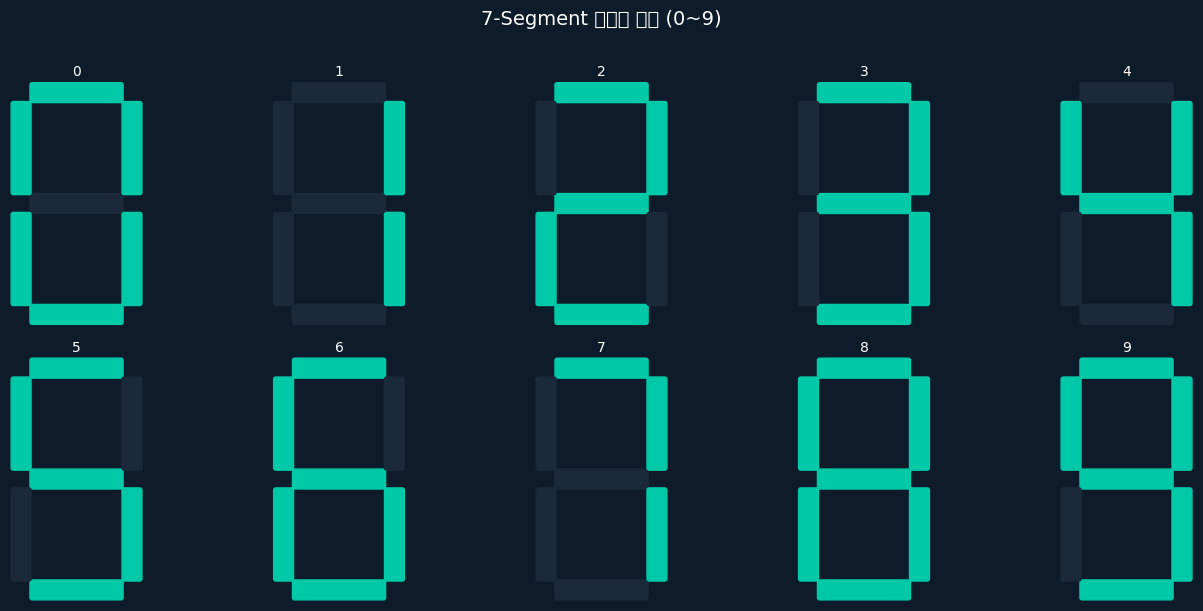

In [13]:
def draw_segment(ax, digit, pattern, noise=False):
    """7-Segment 디스플레이를 matplotlib으로 그립니다."""
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 2.1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_facecolor('#1a1a2e')

    a, b, c, d, e, f, g = pattern
    on_color  = '#00c9a7'
    off_color = '#1a2a3a'

    # 수평 세그먼트 (a, g, d)
    for seg_val, y_pos, label in [(a, 2.0, 'a'), (g, 1.0, 'g'), (d, 0.0, 'd')]:
        color = on_color if seg_val else off_color
        rect = patches.FancyBboxPatch((0.1, y_pos-0.07), 0.8, 0.14,
                                       boxstyle='round,pad=0.02', color=color)
        ax.add_patch(rect)

    # 수직 세그먼트 (f, b, e, c)
    for seg_val, x_pos, y_pos, label in [
        (f, 0.0, 1.1, 'f'), (b, 1.0, 1.1, 'b'),
        (e, 0.0, 0.1, 'e'), (c, 1.0, 0.1, 'c')
    ]:
        color = on_color if seg_val else off_color
        rect = patches.FancyBboxPatch((x_pos-0.07, y_pos), 0.14, 0.8,
                                       boxstyle='round,pad=0.02', color=color)
        ax.add_patch(rect)

    title = f'{digit}' + (' (노이즈)' if noise else '')
    ax.set_title(title, color='white', fontsize=10, pad=4)


# ─── 0~9 이상적 패턴 시각화 ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.patch.set_facecolor('#0d1b2a')
fig.suptitle('7-Segment 이상적 패턴 (0~9)', color='white', fontsize=14, y=1.01)

for i, (digit, pattern) in enumerate(SEGMENTS.items()):
    ax = axes[i // 5][i % 5]
    ax.set_facecolor('#1a1a2e')
    draw_segment(ax, digit, pattern)

plt.tight_layout()
plt.show()

생성된 데이터 형태: X=(2000, 7), y=(2000,)
클래스 분포: {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5): np.int64(200), np.int64(6): np.int64(200), np.int64(7): np.int64(200), np.int64(8): np.int64(200), np.int64(9): np.int64(200)}

학습 데이터: 1600개
테스트 데이터: 400개


C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\2954386538.py:48: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\2954386538.py:48: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\2954386538.py:48: UserWarning: Glyph 51592 (\N{HANGUL SYLLABLE JEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\2954386538.py:48: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\2954386538.py:48: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\2954386538.py:48: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) 

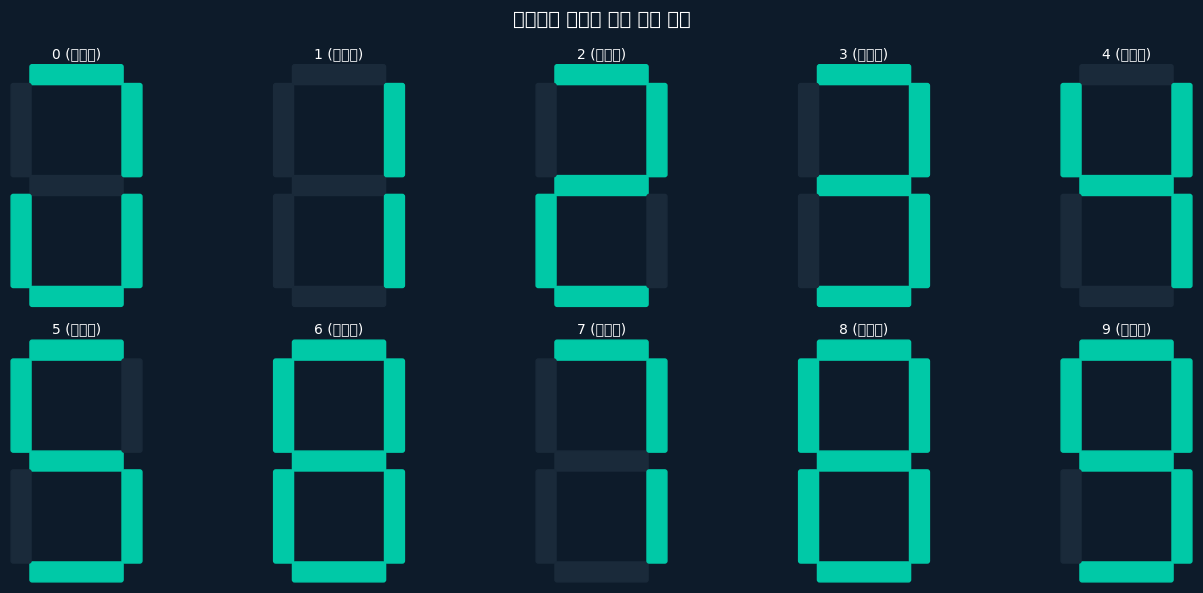

In [14]:
# ─── 데이터 증강: 노이즈 추가 ────────────────────────────────────────────
def augment_data(segments_dict, samples_per_class=200, noise_prob=0.05):
    """
    각 숫자 패턴에 랜덤 노이즈(비트 플립)를 추가하여 학습 데이터를 생성합니다.
    
    Args:
        samples_per_class: 각 클래스당 생성할 샘플 수
        noise_prob: 각 비트가 뒤집힐 확률
    """
    X_list, y_list = [], []
    for digit, pattern in segments_dict.items():
        for _ in range(samples_per_class):
            # 노이즈 생성: 각 비트를 noise_prob 확률로 플립
            noise = np.random.binomial(1, noise_prob, size=7)
            noisy = np.array(pattern) ^ noise  # XOR로 비트 플립
            X_list.append(noisy.astype(np.float32))
            y_list.append(digit)

    return np.array(X_list), np.array(y_list)


X, y = augment_data(SEGMENTS, samples_per_class=200, noise_prob=0.05)
print(f'생성된 데이터 형태: X={X.shape}, y={y.shape}')
print(f'클래스 분포: {dict(zip(*np.unique(y, return_counts=True)))}')

# Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\n학습 데이터: {X_train.shape[0]}개')
print(f'테스트 데이터: {X_test.shape[0]}개')

# PyTorch 텐서로 변환
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)

# 노이즈가 추가된 샘플 시각화
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.patch.set_facecolor('#0d1b2a')
fig.suptitle('노이즈가 추가된 학습 샘플 예시', color='white', fontsize=14)
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    ax = axes[i // 5][i % 5]
    ax.set_facecolor('#1a1a2e')
    draw_segment(ax, i, X_train[idx].astype(int), noise=True)
plt.tight_layout()
plt.show()

---
## Step 3: MLP 모델 정의

```
Input(7) → Linear(32) → ReLU → Linear(16) → ReLU → Linear(10) → Softmax
```

> 💡 `nn.Module`을 상속받아 `__init__`에서 레이어를, `forward`에서 순전파를 정의합니다.

In [15]:
class SevenSegmentNet(nn.Module):
    """
    7-Segment 숫자 분류를 위한 MLP 모델
    
    Architecture:
        Input(7) → FC(32) → ReLU → FC(16) → ReLU → FC(10)
    """
    def __init__(self, input_size=7, hidden1=32, hidden2=16, num_classes=10):
        super(SevenSegmentNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),  # 입력층 → 은닉층 1
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),     # 은닉층 1 → 은닉층 2
            nn.ReLU(),
            nn.Linear(hidden2, num_classes), # 은닉층 2 → 출력층
        )
        # 가중치 초기화 (Xavier Uniform)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """순전파: CrossEntropyLoss가 내부적으로 Softmax를 포함하므로 raw logits 반환"""
        return self.network(x)


# 모델 생성 및 구조 출력
model = SevenSegmentNet().to(device)
print(model)
print(f'\n총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}개')

SevenSegmentNet(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=10, bias=True)
  )
)

총 파라미터 수: 954개


---
## Step 4: 학습 루프

학습 과정:
1. **순전파(Forward Pass)**: 입력 → 모델 → 예측값 계산
2. **손실 계산(Loss)**: 예측값과 실제 레이블 비교
3. **역전파(Backward Pass)**: 그래디언트 계산
4. **가중치 업데이트**: 옵티마이저가 파라미터 조정

In [16]:
# ─── 하이퍼파라미터 ───────────────────────────────────────────────────────
LEARNING_RATE = 0.001
NUM_EPOCHS    = 150

# 손실함수 & 옵티마이저
criterion = nn.CrossEntropyLoss()  # 다중 클래스 분류 손실함수 (Softmax 포함)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 학습 기록 저장
history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

# ─── 학습 루프 ────────────────────────────────────────────────────────────
print(f'학습 시작 (Epochs: {NUM_EPOCHS}, lr: {LEARNING_RATE})')
print('-' * 50)

for epoch in range(NUM_EPOCHS):
    # ── 학습 모드 ──
    model.train()
    optimizer.zero_grad()          # 이전 그래디언트 초기화
    outputs = model(X_train_t)     # 순전파
    loss = criterion(outputs, y_train_t)  # 손실 계산
    loss.backward()                # 역전파
    optimizer.step()               # 가중치 업데이트

    # ── 학습 정확도 ──
    _, predicted_train = torch.max(outputs, 1)
    train_acc = (predicted_train == y_train_t).float().mean().item()

    # ── 테스트 평가 ──
    model.eval()
    with torch.no_grad():
        test_outputs  = model(X_test_t)
        _, predicted_test = torch.max(test_outputs, 1)
        test_acc = (predicted_test == y_test_t).float().mean().item()

    # 기록 저장
    history['train_loss'].append(loss.item())
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    # 진행 상황 출력 (매 30 epoch)
    if (epoch + 1) % 30 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:>3}/{NUM_EPOCHS}]  '
              f'Loss: {loss.item():.4f}  '
              f'Train Acc: {train_acc*100:.1f}%  '
              f'Test Acc: {test_acc*100:.1f}%')

print('\n✅ 학습 완료!')

학습 시작 (Epochs: 150, lr: 0.001)
--------------------------------------------------
Epoch [  1/150]  Loss: 2.3503  Train Acc: 16.7%  Test Acc: 17.0%
Epoch [ 30/150]  Loss: 2.0353  Train Acc: 41.9%  Test Acc: 39.8%
Epoch [ 60/150]  Loss: 1.7376  Train Acc: 43.2%  Test Acc: 42.5%
Epoch [ 90/150]  Loss: 1.4105  Train Acc: 74.1%  Test Acc: 73.0%
Epoch [120/150]  Loss: 1.0781  Train Acc: 81.3%  Test Acc: 80.0%
Epoch [150/150]  Loss: 0.8289  Train Acc: 84.2%  Test Acc: 82.5%

✅ 학습 완료!


C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\3451951863.py:29: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\3451951863.py:29: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\3451951863.py:29: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\3451951863.py:29: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\3451951863.py:29: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\3451951863.py:29: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from fon

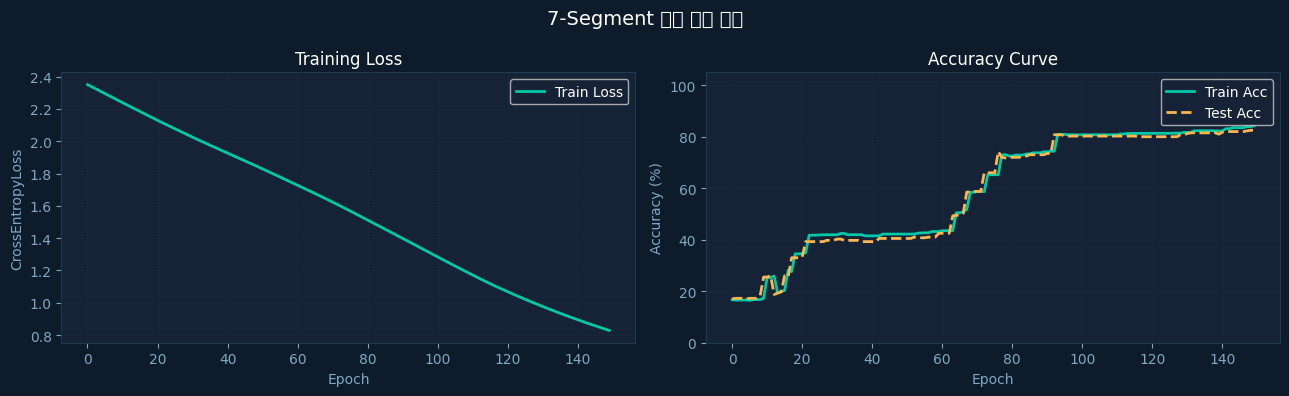

최종 Test Accuracy: 82.50%


In [17]:
# ─── 학습 곡선 시각화 ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0d1b2a')
for ax in [ax1, ax2]:
    ax.set_facecolor('#162236')
    ax.tick_params(colors='#7fa8c4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e3a54')

# 손실 곡선
ax1.plot(history['train_loss'], color='#00c9a7', linewidth=2, label='Train Loss')
ax1.set_title('Training Loss', color='white', fontsize=12)
ax1.set_xlabel('Epoch', color='#7fa8c4')
ax1.set_ylabel('CrossEntropyLoss', color='#7fa8c4')
ax1.legend(facecolor='#162236', labelcolor='white')
ax1.grid(alpha=0.2, color='#1e3a54')

# 정확도 곡선
ax2.plot([a*100 for a in history['train_acc']], color='#00c9a7', linewidth=2, label='Train Acc')
ax2.plot([a*100 for a in history['test_acc']],  color='#ffb74d', linewidth=2, label='Test Acc', linestyle='--')
ax2.set_title('Accuracy Curve', color='white', fontsize=12)
ax2.set_xlabel('Epoch', color='#7fa8c4')
ax2.set_ylabel('Accuracy (%)', color='#7fa8c4')
ax2.set_ylim(0, 105)
ax2.legend(facecolor='#162236', labelcolor='white')
ax2.grid(alpha=0.2, color='#1e3a54')

plt.suptitle('7-Segment 모델 학습 곡선', color='white', fontsize=14)
plt.tight_layout()
plt.show()

print(f'최종 Test Accuracy: {history["test_acc"][-1]*100:.2f}%')

---
## Step 5: 추론 및 결과 분석

In [18]:
# ─── 이상적 패턴으로 추론 ────────────────────────────────────────────────
model.eval()
print('이상적 패턴으로 추론 결과:')
print(f'{"입력":>20} | {"실제":>4} | {"예측":>4} | {"확신도":>6}')
print('-' * 45)

for digit, pattern in SEGMENTS.items():
    x = torch.FloatTensor([pattern]).to(device)
    with torch.no_grad():
        output = model(x)
        probs  = torch.softmax(output, dim=1)
        pred   = torch.argmax(probs, dim=1).item()
        conf   = probs[0][pred].item()
    status = '✅' if pred == digit else '❌'
    print(f'{str(pattern):>20} | {digit:>4} | {pred:>4} | {conf*100:>5.1f}%  {status}')

이상적 패턴으로 추론 결과:
                  입력 |   실제 |   예측 |    확신도
---------------------------------------------
[1, 1, 1, 1, 1, 1, 0] |    0 |    0 |  53.9%  ✅
[0, 1, 1, 0, 0, 0, 0] |    1 |    1 |  39.8%  ✅
[1, 1, 0, 1, 1, 0, 1] |    2 |    2 |  70.5%  ✅
[1, 1, 1, 1, 0, 0, 1] |    3 |    3 |  63.6%  ✅
[0, 1, 1, 0, 0, 1, 1] |    4 |    4 |  72.6%  ✅
[1, 0, 1, 1, 0, 1, 1] |    5 |    5 |  66.0%  ✅
[1, 0, 1, 1, 1, 1, 1] |    6 |    6 |  69.4%  ✅
[1, 1, 1, 0, 0, 0, 0] |    7 |    7 |  47.7%  ✅
[1, 1, 1, 1, 1, 1, 1] |    8 |    8 |  45.3%  ✅
[1, 1, 1, 1, 0, 1, 1] |    9 |    9 |  54.5%  ✅


C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\499607653.py:26: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\499607653.py:26: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\499607653.py:26: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\499607653.py:26: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\499607653.py:26: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyoun\AppData\Local\Temp\ipykernel_7672\499607653.py:26: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) Deja

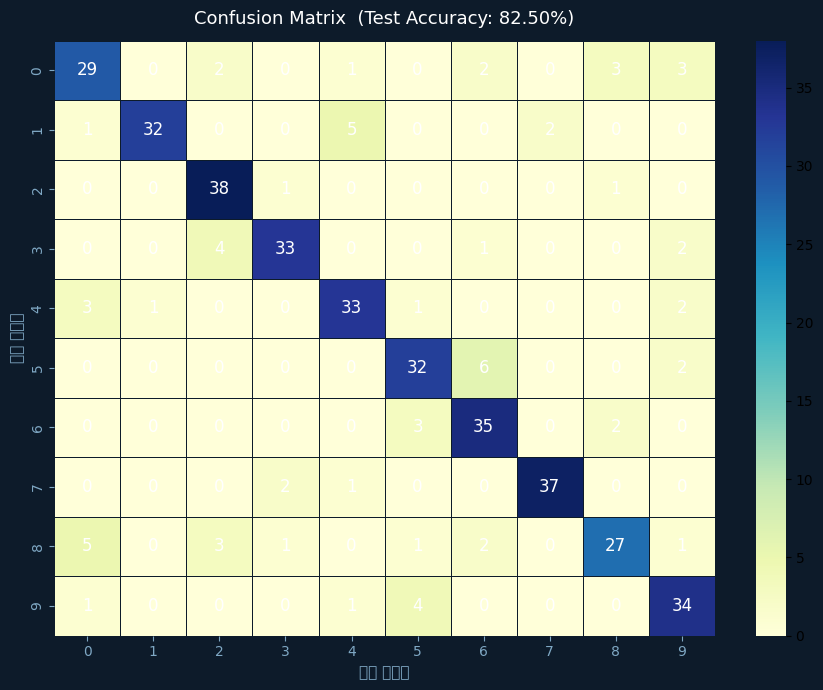


분류 보고서:
              precision    recall  f1-score   support

           0       0.74      0.72      0.73        40
           1       0.97      0.80      0.88        40
           2       0.81      0.95      0.87        40
           3       0.89      0.82      0.86        40
           4       0.80      0.82      0.81        40
           5       0.78      0.80      0.79        40
           6       0.76      0.88      0.81        40
           7       0.95      0.93      0.94        40
           8       0.82      0.68      0.74        40
           9       0.77      0.85      0.81        40

    accuracy                           0.82       400
   macro avg       0.83      0.82      0.82       400
weighted avg       0.83      0.82      0.82       400



In [20]:
# ─── Confusion Matrix ────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    outputs   = model(X_test_t)
    _, preds  = torch.max(outputs, 1)
    y_pred    = preds.cpu().numpy()
    y_true    = y_test_t.cpu().numpy()

cm = confusion_matrix(y_true, y_pred)
acc = (y_pred == y_true).mean()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#162236')

sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=range(10), yticklabels=range(10),
            ax=ax, linewidths=0.5, linecolor='#0d1b2a',
            annot_kws={'size': 12, 'color': 'white'})

ax.set_title(f'Confusion Matrix  (Test Accuracy: {acc*100:.2f}%)',
             color='white', fontsize=13, pad=12)
ax.set_xlabel('예측 레이블', color='#7fa8c4', fontsize=11)
ax.set_ylabel('실제 레이블', color='#7fa8c4', fontsize=11)
ax.tick_params(colors='#7fa8c4')
plt.tight_layout()
plt.show()

print('\n분류 보고서:')
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)]))

In [12]:
# ─── 모델 저장 및 로드 ───────────────────────────────────────────────────
torch.save(model.state_dict(), 'seven_segment_model.pth')
print('모델 저장 완료: seven_segment_model.pth')

# 모델 로드 예시
loaded_model = SevenSegmentNet().to(device)
loaded_model.load_state_dict(torch.load('seven_segment_model.pth', map_location=device))
loaded_model.eval()
print('모델 로드 성공 ✅')

모델 저장 완료: seven_segment_model.pth
모델 로드 성공 ✅


---
## ✏️ Step 6: 도전 과제

아래 과제를 직접 코드로 구현해 보세요!

### 🟢 기초
1. 노이즈 확률(`noise_prob`)을 `0.1`, `0.2`로 높여보세요. 정확도가 어떻게 변하나요?
2. Hidden Layer 크기를 `64 → 32`로 바꿔보세요.

### 🟡 중급
3. Adam 대신 `SGD`(momentum=0.9) 옵티마이저를 사용해보세요.
4. 학습률(`lr`)을 `0.01`, `0.0001`로 바꿔 수렴 속도를 비교하세요.

### 🔴 심화
5. `nn.Dropout(0.3)`을 은닉층 사이에 추가해보세요. 효과가 있나요?
6. 새로운 "숫자"(예: 0~9 외의 특수 패턴)를 직접 정의하여 클래스를 추가해보세요.

In [ ]:
# ✏️ 여기에 도전 과제 코드를 작성하세요!

# 예시: noise_prob 변경 실험
# X_noisy, y_noisy = augment_data(SEGMENTS, samples_per_class=200, noise_prob=0.15)
# ... (학습 코드 반복)

print('도전 과제를 직접 구현해보세요! 🚀')